# Module 3 — Multi-Year Admissions Trend & Forecast

**Goal:** merge 4 years of real NHS Digital diagnosis files (2021-22 through 2024-25) into one trend line, and forecast the next 3 years.

Two file formats needed two loaders: the 2024-25 file is long-format CSV; 2021-22/2022-23/2023-24 are wide-format Excel with slightly different column names each year (handled with flexible keyword matching).

## 1. Load and merge all 4 years

In [8]:
import sys, os
from pathlib import Path

p = Path.cwd()
while not (p / "README.md").exists() and p != p.parent:
    p = p.parent

os.chdir(p)
if str(p / "src") not in sys.path:
    sys.path.insert(0, str(p / "src"))

print("Working directory set to:", os.getcwd())

Working directory set to: c:\PROJECTSSSSS\uk-ed-analytics


In [9]:
import os
os.listdir('data/raw')

['hosp-epis-stat-admi-diag-2021-22-tab.xlsx',
 'hosp-epis-stat-admi-diag-2022-23-tab_V2.xlsx',
 'hosp-epis-stat-admi-diag-2023-24-tab.xlsx',
 'hosp-epis-stat-admi-diag-2024-25.csv',
 'hosp-epis-stat-admi-summary-tabs-2024-25.xlsx',
 'nhs_ed_admissions_england.csv',
 'NOMIS-newfile.xlsx',
 'nomis_2026_09_22_060553.xlsx',
 'nomis_2026_09_22_082351.xlsx',
 'nomis_mortality_2024.xlsx']

In [10]:
import sys
sys.path.append('src')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from load_nhs_diagnosis_xlsx import main as load_xlsx_main
load_xlsx_main()

Parsed 2021-22: 9 rows
Parsed 2022-23: 9 rows
Parsed 2023-24: 9 rows

Saved -> data/processed/nhs_ed_subtypes_multiyear.csv
   financial_year FCE_SUM FAE_SUM
0         2021-22    8674    5559
9         2022-23    7339    4462
18        2023-24    7522    4471


In [11]:
multi = pd.read_csv('data/processed/nhs_ed_subtypes_multiyear.csv')
y2425 = pd.read_csv('data/processed/nhs_ed_subtypes_2024-25.csv')[
    ['financial_year','Code','diagnosis_label','FCE_SUM','FAE_SUM','FCE_Male_Sum','FCE_Female_Sum']
]
full = pd.concat([multi, y2425], ignore_index=True).sort_values(['Code','financial_year'])
full.to_csv('data/processed/nhs_ed_subtypes_all_years.csv', index=False)

full[full.Code=='F50'][['financial_year','FCE_SUM','FAE_SUM']]

,financial_year,FCE_SUM,FAE_SUM
0,2021-22,8674.0,5559.0
9,2022-23,7339.0,4462.0
18,2023-24,7522.0,4471.0
27,2024-25,7884.0,4498.0


**The trend:** 8,674 → 7,339 → 7,522 → 7,884. A dip after 2021-22, then recovering over the following two years.

## 2. Forecast the next 3 years

**Honesty note before we start:** 4 annual points is a genuinely thin sample for time-series forecasting. There's no reliable seasonal pattern to model with only annual data, so this deliberately uses simple, defensible methods (linear trend regression + Holt's Linear Exponential Smoothing) rather than a full SARIMA model, which would overfit 4 points badly. Treat the forecast as directional, not precise.

In [12]:
df = pd.read_csv('data/processed/f50_yearly_series.csv')
df

,financial_year,admissions,year_end
0,2021-22,8674.0,2022
1,2022-23,7339.0,2023
2,2023-24,7522.0,2024
3,2024-25,7884.0,2025


In [13]:
from forecast_admissions import (
    linear_trend_forecast, holt_forecast, leave_last_out_eval, plot_forecast
)

leave_last_out_eval(df)

=== Leave-last-year-out check (predicting last known year from prior years) ===
Actual 2024-25: 7,884
Linear trend predicted: 6,693  (abs error: 1,191)
Holt's linear predicted: 6,693  (abs error: 1,191)



**Reading the check above:** both methods predicted the last known year (2024-25) with a ~1,200-episode error when trained on only the 3 prior years. That's a large error relative to the ~7,000-8,000 scale of the series — a clear signal to treat the forward forecast with real caution.

In [14]:
FORECAST_YEARS = 3
lt_years, lt_forecast, _ = linear_trend_forecast(df, FORECAST_YEARS)
holt_years, holt_vals, _ = holt_forecast(df, FORECAST_YEARS)

for y, lt, h in zip(lt_years, lt_forecast, holt_vals):
    print(f"FY ending {y}: linear trend = {lt:,.0f} | Holt's linear = {h:,.0f}")

plot_forecast(df, lt_years, lt_forecast, holt_years, holt_vals)

FY ending 2026: linear trend = 7,308 | Holt's linear = 7,308
FY ending 2027: linear trend = 7,089 | Holt's linear = 7,089
FY ending 2028: linear trend = 6,871 | Holt's linear = 6,871
Saved forecast plot to reports/figures/admissions_forecast.png


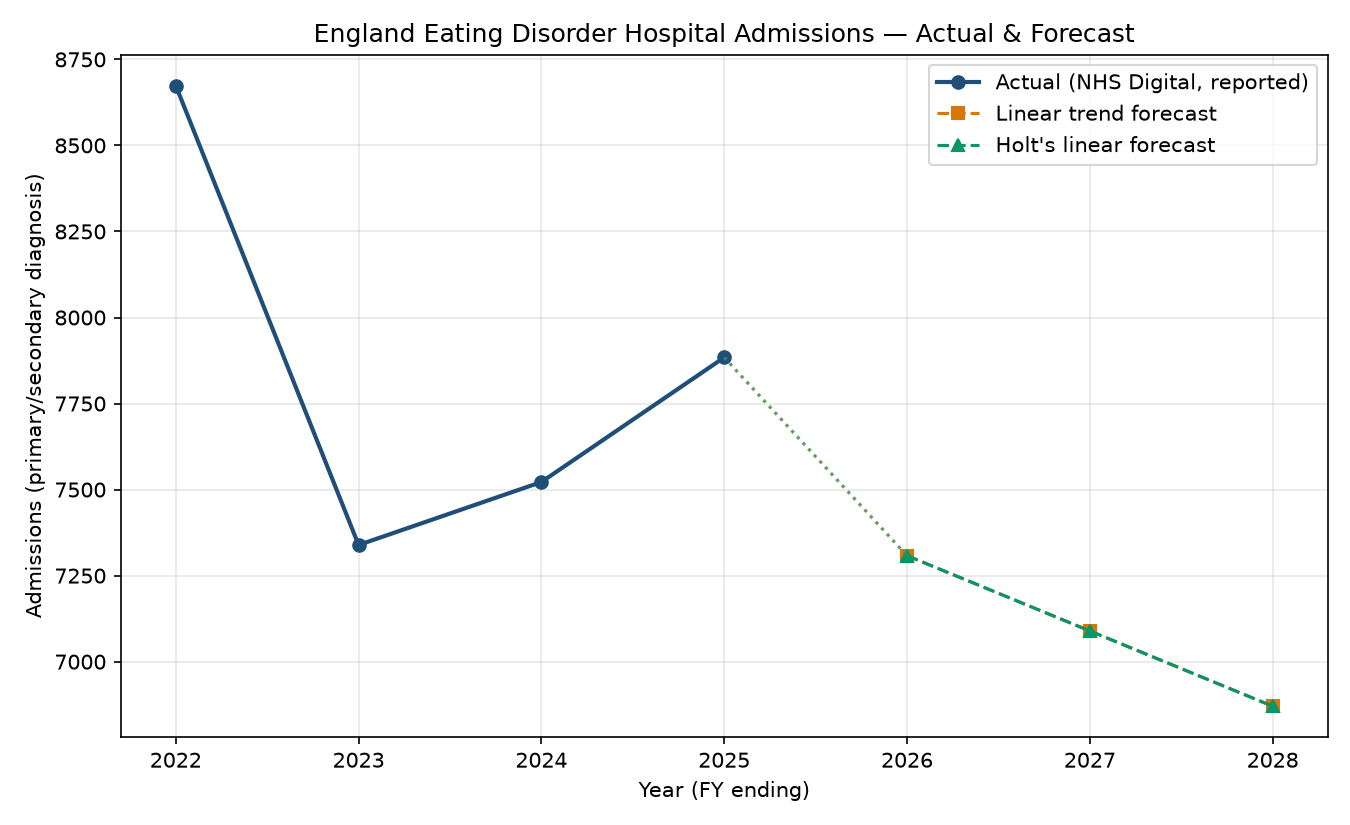

In [15]:
from IPython.display import Image
Image('reports/figures/admissions_forecast.png')

## Takeaways

- Real admissions dipped post-2021-22 and have been recovering since
- Both forecasting methods converge to nearly the same projection — expected given how little data separates them, not a sign of high confidence
- If more historical years become available (older NHS Digital editions), this forecast would improve meaningfully — worth revisiting

